# Largest pair-rule gaps

This exploratory investigation finds large, visible direction-specific changes without
using rule names. Statistical and strong-visible candidates are kept as separate reasons;
small FOV groups cannot enter through visual strength alone.

## Setup

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd
from IPython.display import display

ROOT = next(
    folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (folder / "result_summary" / "data_helper.py").exists()
)
sys.path[:0] = [
    str(ROOT / "result_summary"),
    str(ROOT / "result_summary" / "differential_rules" / "scripts"),
]

import data_helper as dh
import differential_stats as ds
import differential_vis as dv
import compare_rules as cr

warnings.filterwarnings("ignore")

RULE_MAX_ITEMS = 2
METRIC = "Lift"
METRIC_REFERENCE = 1
SCORE_COLUMN = "Clinical score"
STAGES = ["Control", "Mild", "Severe"]
ORGANS = ["Colon", "Duodenum"]
TEST_UNIT = "Biopsy"

MIN_CELLS = 20
MIN_PRESENT = 3
MIN_ELIGIBLE = 3
N_PERMUTATIONS = 5_000
FDR_CUTOFF = 0.05
STATISTICAL_MIN_EFFECT = {"prevalence": 0.20, "metric": 0.25}
VISUAL_MIN_EFFECT = {"prevalence": 0.30, "metric": 0.30}
VISUAL_MIN_FOVS = 10
MAX_STATISTICAL = 1
MAX_VISUAL = 2

DIRECTIONS = {1: "attraction", -1: "avoidance"}
MEASURES = ["prevalence", "metric"]

## Data

In [2]:
df_cells, df_fovs, _ = dh.load_spatial_data()
df_results = dh.load_results(rule_max_items=RULE_MAX_ITEMS)
rule_matrix = dh.prepare_rules(df_results)
all_states, eligibility, eligible_states = ds.state_tables(
    rule_matrix, df_cells, df_fovs["FOV"], MIN_CELLS
)
print(f"{len(rule_matrix)} rows; {all_states.shape[0]} rules × {all_states.shape[1]} FOVs")

Dropped 21 FOVs: Control_S
Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71
Read results_CN_pairwise.csv
Loaded 16600 rules.
Kept 9719 rules at FDR <= 0.05.
Kept 9719 rules that add information.
Kept 9647 rules naming no Unidentified.
Kept 4100 rules (max_items=2, kind=attracts).
3146 rows; 319 rules × 267 FOVs


## Selection logic

In [3]:
def values_for(state, measure):
    if measure == "prevalence":
        return ds.direction_matrix(eligible_states, state)
    return ds.direction_metric_matrix(
        rule_matrix, eligible_states, eligibility, METRIC, state
    )


def run_screen(values, organ):
    fov_screen = ds.severity_screen(
        values, df_fovs, organ, SCORE_COLUMN, STAGES,
        min_eligible=MIN_ELIGIBLE, min_present=MIN_PRESENT,
        n_permutations=N_PERMUTATIONS,
    )
    biopsy_values = ds.aggregate_fovs(values, df_fovs, TEST_UNIT)
    biopsy_screen = ds.severity_screen(
        biopsy_values, df_fovs, organ, SCORE_COLUMN, STAGES,
        min_eligible=MIN_ELIGIBLE, min_present=MIN_PRESENT,
        n_permutations=N_PERMUTATIONS, unit_col=TEST_UNIT,
    )
    return {"FOV": fov_screen, TEST_UNIT: biopsy_screen}


def build_specs():
    specs, tests = [], {}
    for measure in MEASURES:
        for state, direction in DIRECTIONS.items():
            values = values_for(state, measure)
            for organ in ORGANS:
                key = measure, state, organ
                tests[key] = run_screen(values, organ)
                fov_evidence = ds.evidence_table(*tests[key]["FOV"], stages=STAGES)
                biopsy_evidence = ds.evidence_table(*tests[key][TEST_UNIT], stages=STAGES)
                selected = ds.select_candidates(
                    biopsy_evidence, fov_evidence,
                    fdr_cutoff=FDR_CUTOFF,
                    statistical_min_effect=STATISTICAL_MIN_EFFECT[measure],
                    visual_min_effect=VISUAL_MIN_EFFECT[measure],
                    visual_min_n=VISUAL_MIN_FOVS,
                    max_statistical=MAX_STATISTICAL,
                    max_visual=MAX_VISUAL,
                )
                for row in selected.to_dict("records"):
                    specs.append({
                        **row, "organ": organ, "score": SCORE_COLUMN,
                        "state": state, "direction": direction,
                        "measure": measure, "test_unit": TEST_UNIT.lower(),
                    })
    return specs, tests

In [4]:
def figure_name(spec, kind):
    rule = spec["rule"].replace(" -> ", "_to_").replace(" ", "")
    score = SCORE_COLUMN.split()[0].lower()
    return (
        f"gap_{spec['measure']}_{spec['direction']}_"
        f"{spec['organ']}_{score}_{rule}_{kind}.pdf"
    )


def show_selected(index):
    """One automatic gap candidate in the shared summary style."""
    if index >= len(SPECS):
        print(f"no rule at index {index}; the screen selected {len(SPECS)}")
        return
    spec = SPECS[index]
    key = spec["measure"], spec["state"], spec["organ"]
    ordered, pairs = TESTS[key][TEST_UNIT]
    scoped = (spec["organ"], SCORE_COLUMN)
    label = f"{spec['direction']} {spec['measure']}"
    print(
        f"[{index}] {spec['organ']} · {spec['rule']} · {label} · "
        f"{spec['selection']}"
    )
    dv.plot_rule_summary(
        all_states, eligibility, df_cells, rule_matrix, df_fovs,
        spec, STAGES, metric=METRIC, reference=METRIC_REFERENCE,
        trend_results={scoped: ordered}, pair_results={scoped: pairs},
        state=spec["state"], test_label=label,
        save=figure_name(spec, "summary"),
    )
    examples = ds.representative_fovs(
        rule_matrix, eligibility, df_fovs, spec["rule"], spec["organ"],
        SCORE_COLUMN, STAGES, METRIC, state=spec["state"],
    )
    cr.plot_rule_fovs(
        examples, STAGES, df_cells, df_fovs, spec["organ"], SCORE_COLUMN,
        min_cells=MIN_CELLS,
        save=figure_name(spec, "fovs"),
    )

## Automatically selected candidates

In [5]:
SPECS, TESTS = build_specs()
print(f"The screen selected {len(SPECS)} rules")
display(pd.DataFrame(SPECS))

The screen selected 7 rules


,rule,selection,best_fdr,statistical_effect,visual_effect,visual_min_n,best_biopsy_test,biopsy_min_n,statistical_test,visual_test,organ,score,state,direction,measure,test_unit
0,CD4T -> Plasma,strong visible effect,0.322981,NaN,0.518333,24.0,Control vs Severe,4,,Control vs Severe,Colon,Clinical score,1,attraction,prevalence,biopsy
1,Neuron -> Macrophage,strong visible effect,0.916746,NaN,-0.511905,12.0,Control vs Mild,4,,Control vs Mild,Colon,Clinical score,1,attraction,prevalence,biopsy
2,SMV -> Endothelial,strong visible effect,0.370000,NaN,1.202490,11.0,Control vs Severe,4,,Control vs Severe,Colon,Clinical score,1,attraction,metric,biopsy
3,Epithelial -> Goblet,strong visible effect,0.659868,NaN,-0.356997,22.0,Mild vs Severe,4,,Control vs Severe,Colon,Clinical score,1,attraction,metric,biopsy
4,Paneth -> Epithelial,statistical,0.019596,0.640231,NaN,NaN,ordered,4,ordered,,Duodenum,Clinical score,1,attraction,metric,biopsy
5,Plasma_CD38 -> Plasma,strong visible effect,0.224422,NaN,-0.318910,11.0,Control vs Severe,7,,Control vs Severe,Duodenum,Clinical score,1,attraction,metric,biopsy
6,Goblet -> Epithelial,strong visible effect,0.032194,NaN,0.307438,13.0,ordered,5,,ordered,Duodenum,Clinical score,1,attraction,metric,biopsy


[0] Colon · CD4T -> Plasma · attraction prevalence · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_CD4T_to_Plasma_summary.pdf


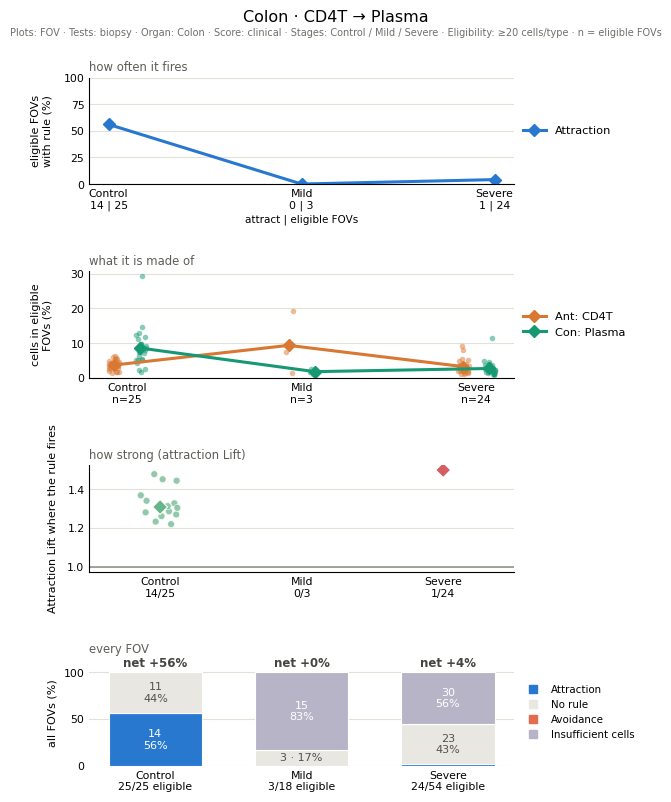

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_CD4T_to_Plasma_fovs_attraction.pdf


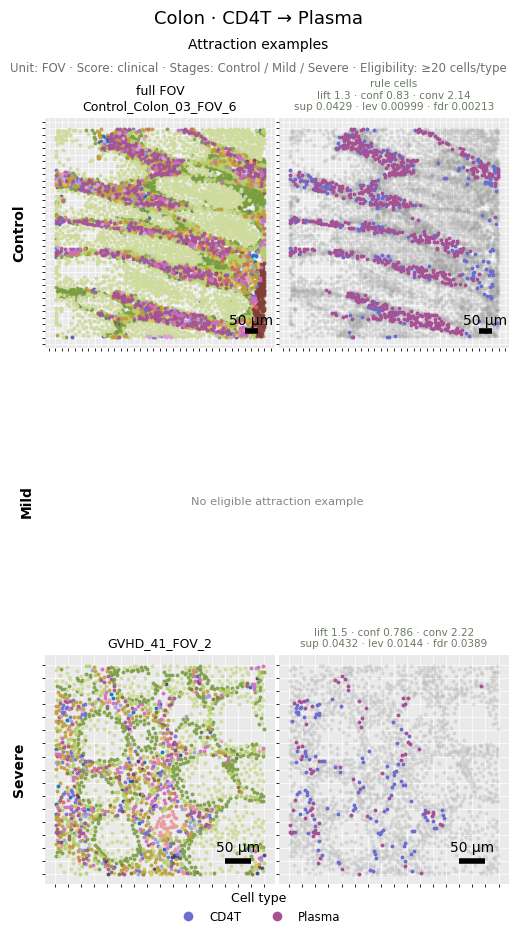

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_CD4T_to_Plasma_fovs_no_rule.pdf


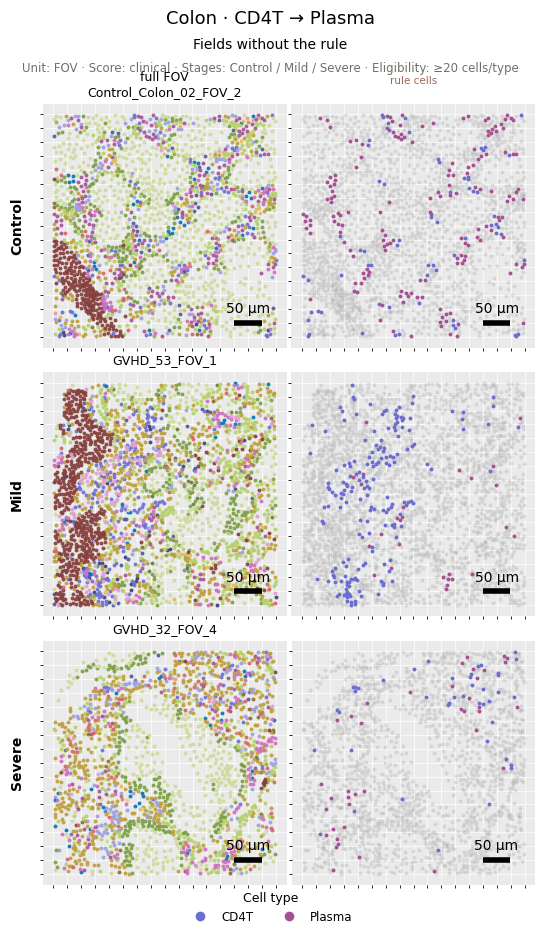

In [6]:
show_selected(0)

[1] Colon · Neuron -> Macrophage · attraction prevalence · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_Neuron_to_Macrophage_summary.pdf


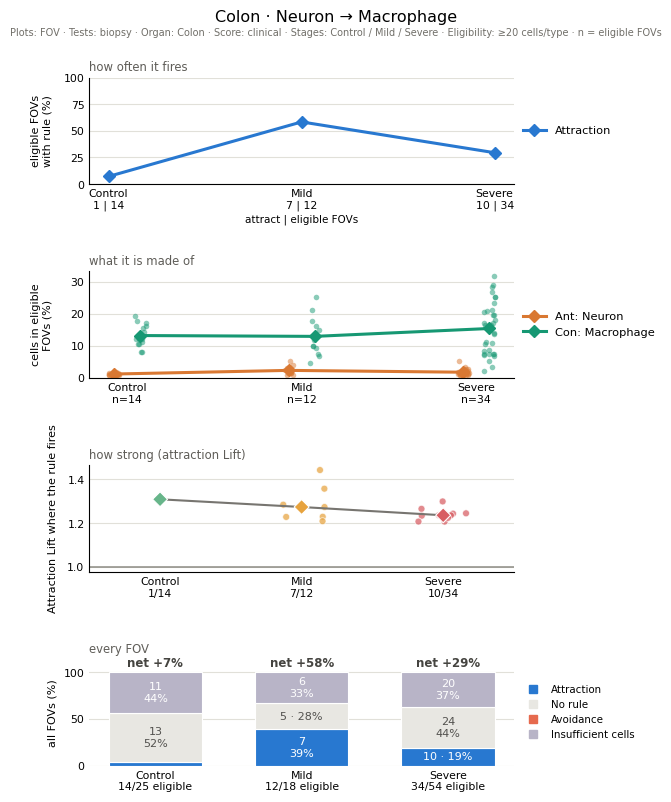

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_Neuron_to_Macrophage_fovs_attraction.pdf


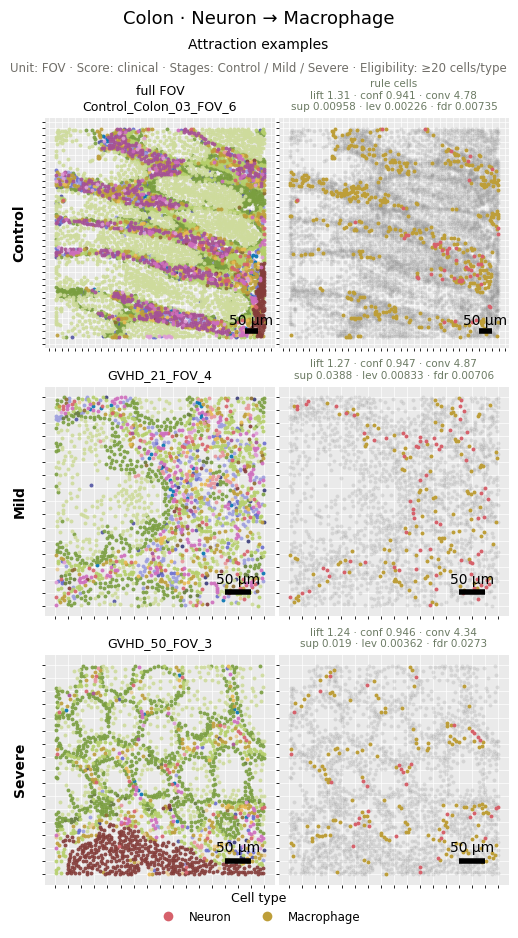

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_prevalence_attraction_Colon_clinical_Neuron_to_Macrophage_fovs_no_rule.pdf


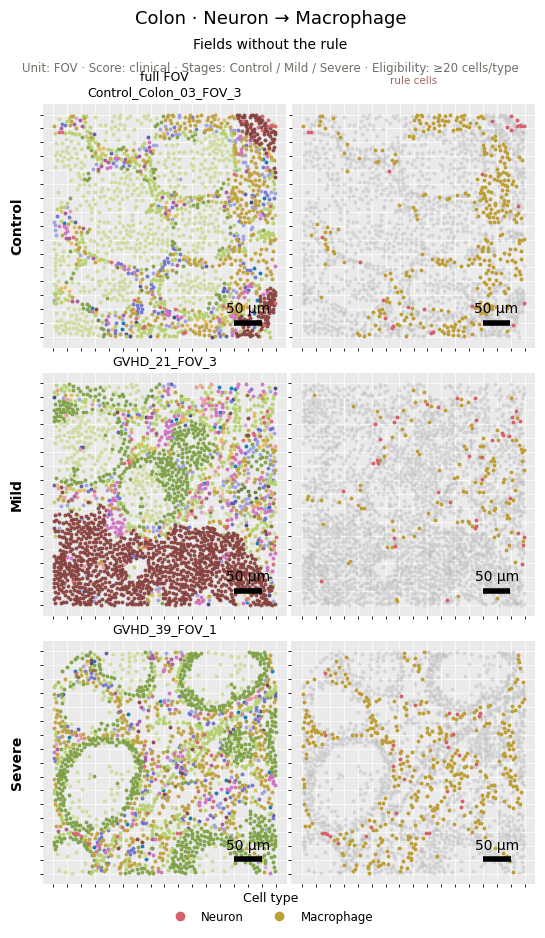

In [7]:
show_selected(1)

[2] Colon · SMV -> Endothelial · attraction metric · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_SMV_to_Endothelial_summary.pdf


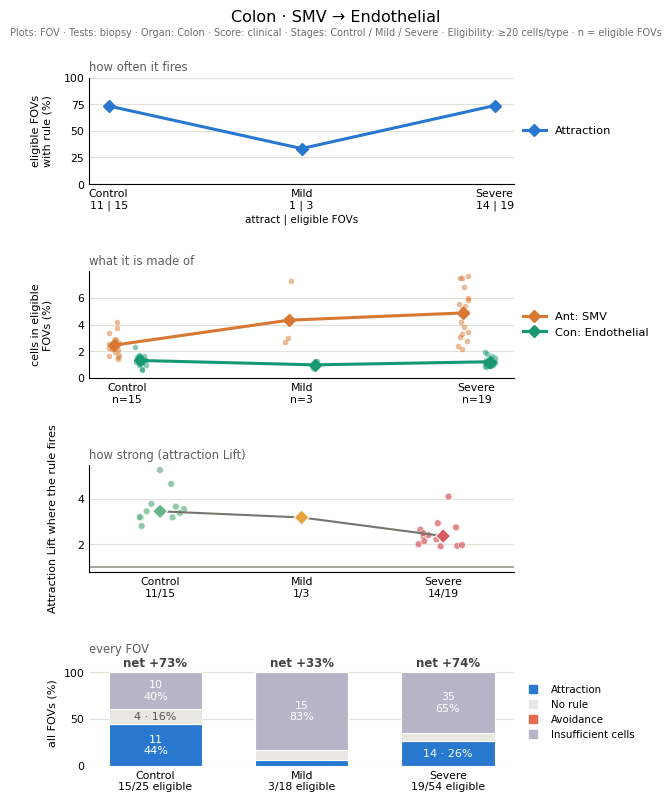

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_SMV_to_Endothelial_fovs_attraction.pdf


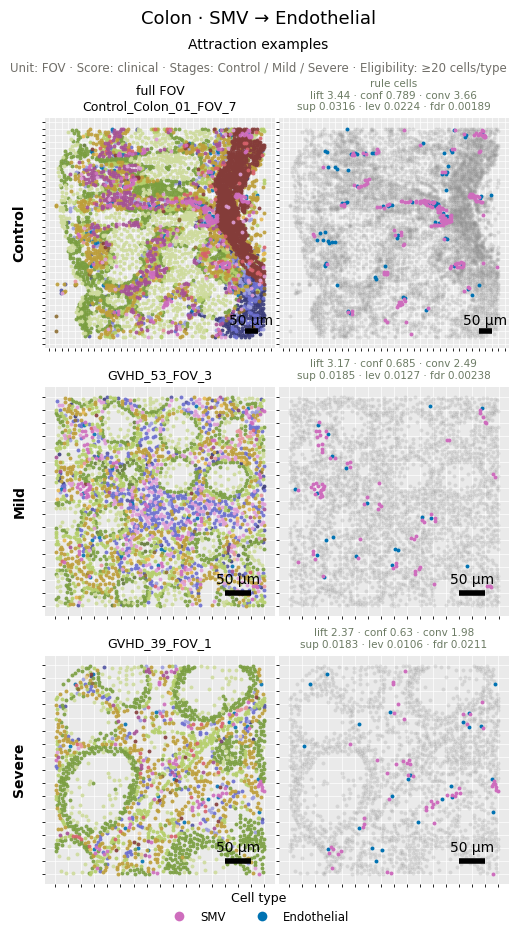

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_SMV_to_Endothelial_fovs_no_rule.pdf


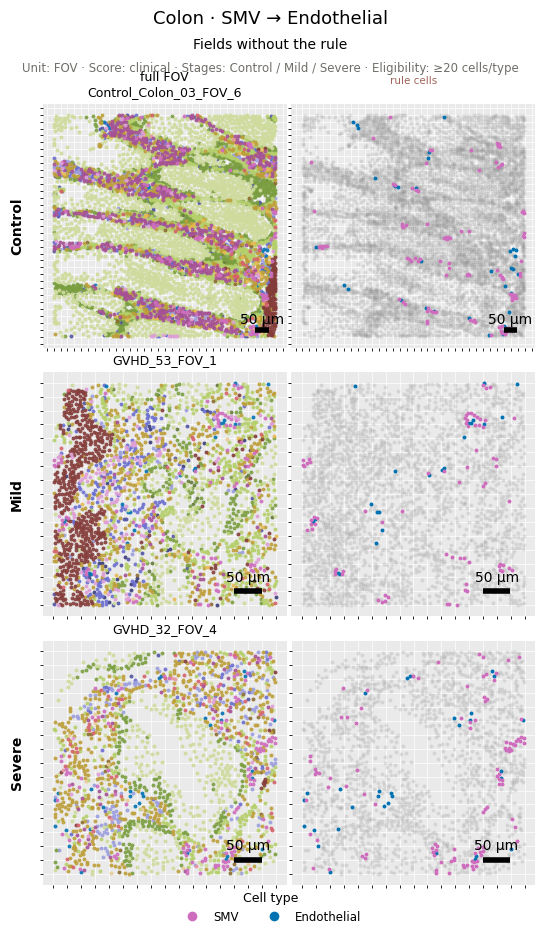

In [8]:
show_selected(2)

[3] Colon · Epithelial -> Goblet · attraction metric · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_Epithelial_to_Goblet_summary.pdf


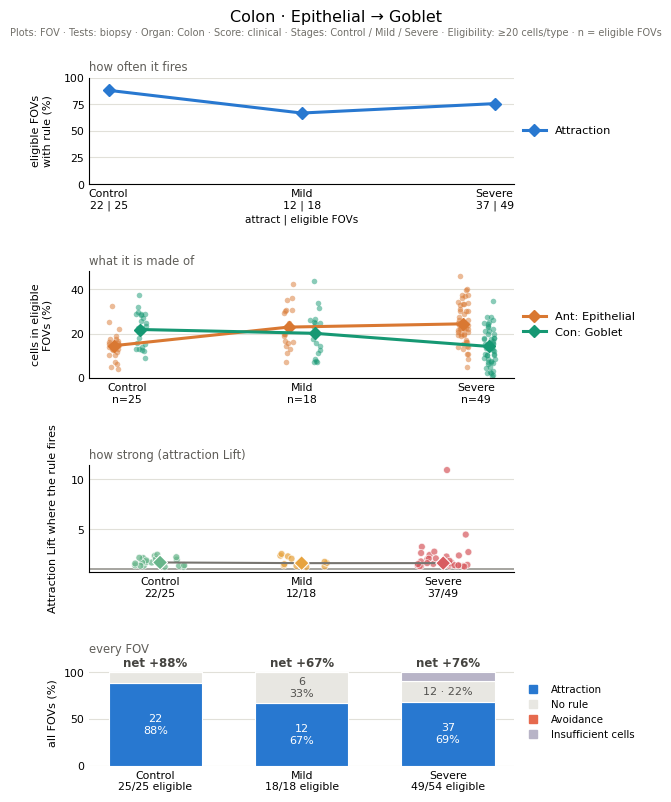

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_Epithelial_to_Goblet_fovs_attraction.pdf


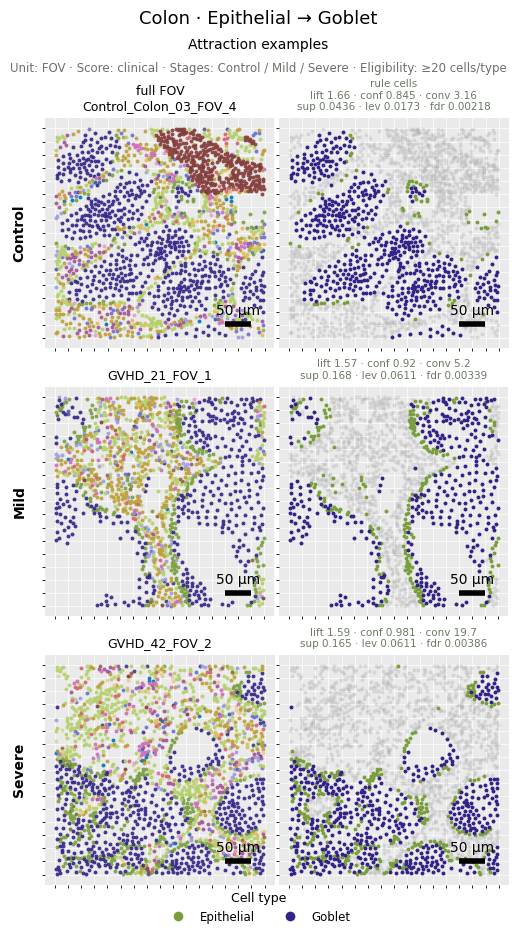

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Colon_clinical_Epithelial_to_Goblet_fovs_no_rule.pdf


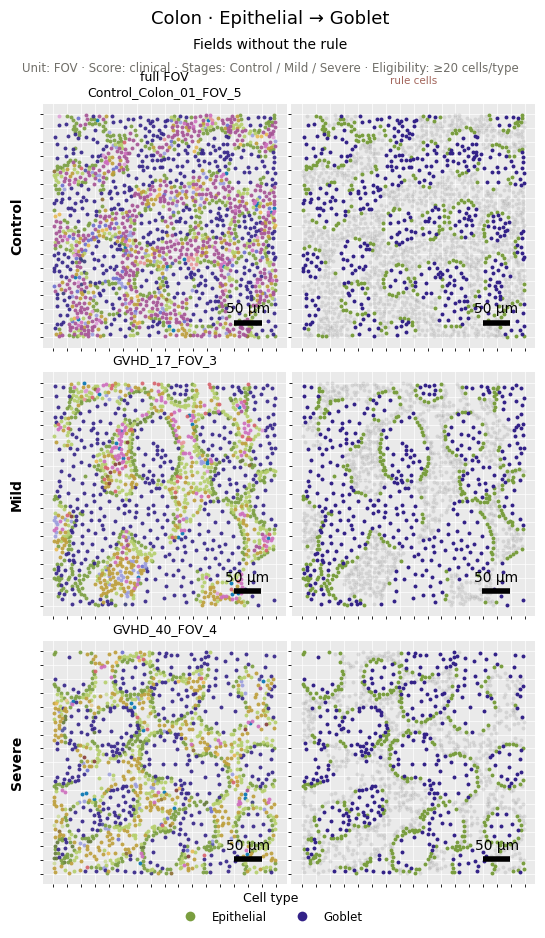

In [9]:
show_selected(3)

[4] Duodenum · Paneth -> Epithelial · attraction metric · statistical
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Paneth_to_Epithelial_summary.pdf


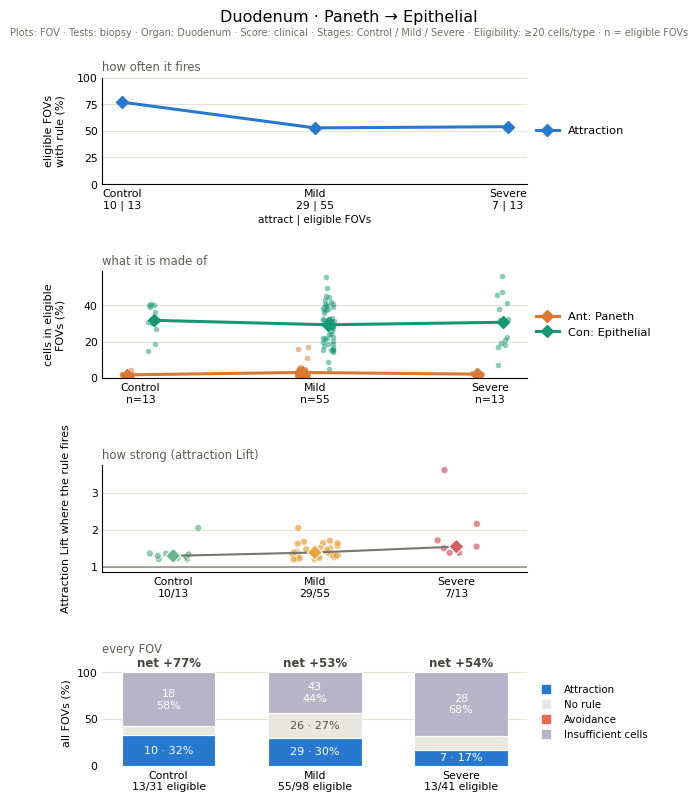

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Paneth_to_Epithelial_fovs_attraction.pdf


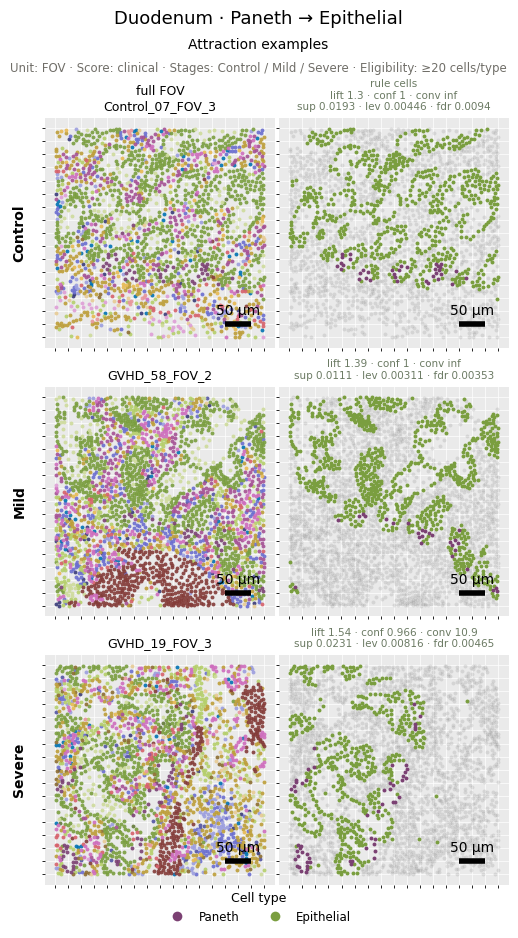

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Paneth_to_Epithelial_fovs_no_rule.pdf


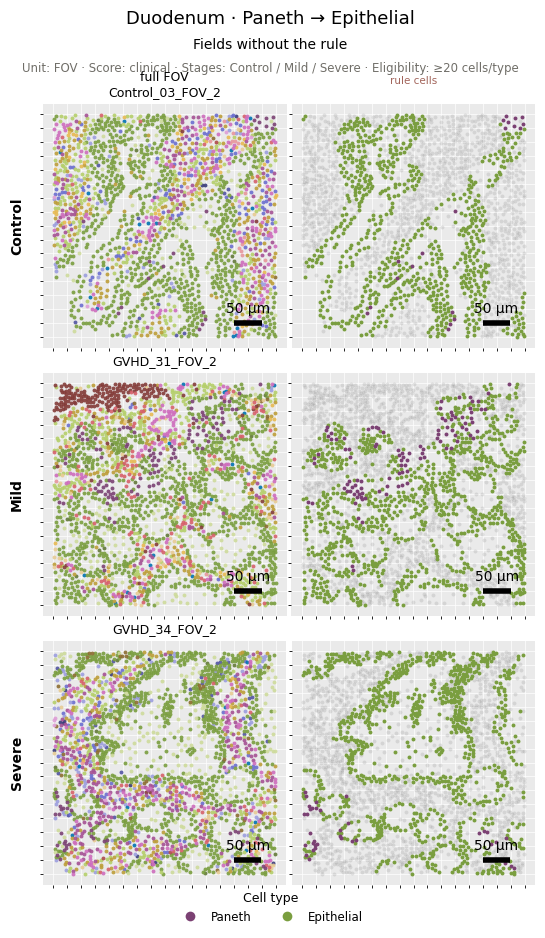

In [10]:
show_selected(4)

[5] Duodenum · Plasma_CD38 -> Plasma · attraction metric · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Plasma_CD38_to_Plasma_summary.pdf


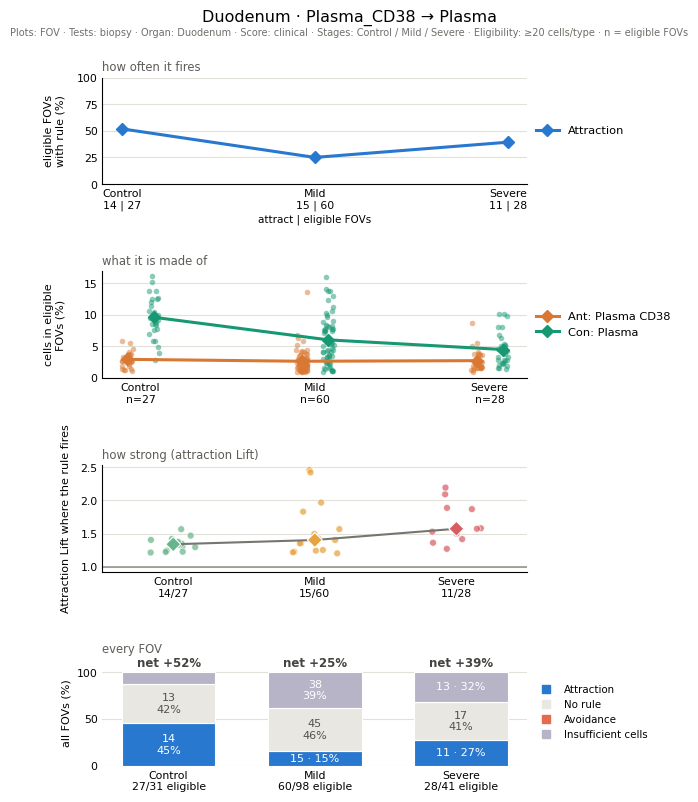

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Plasma_CD38_to_Plasma_fovs_attraction.pdf


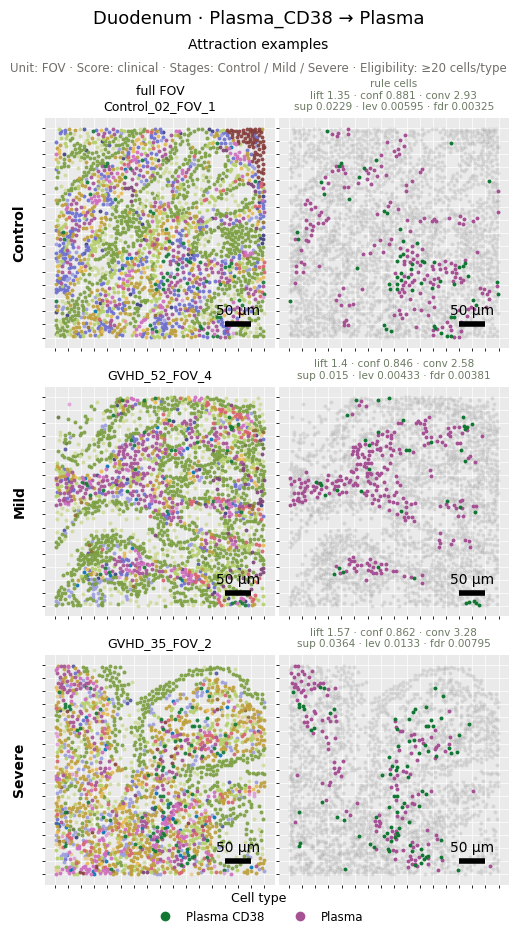

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Plasma_CD38_to_Plasma_fovs_no_rule.pdf


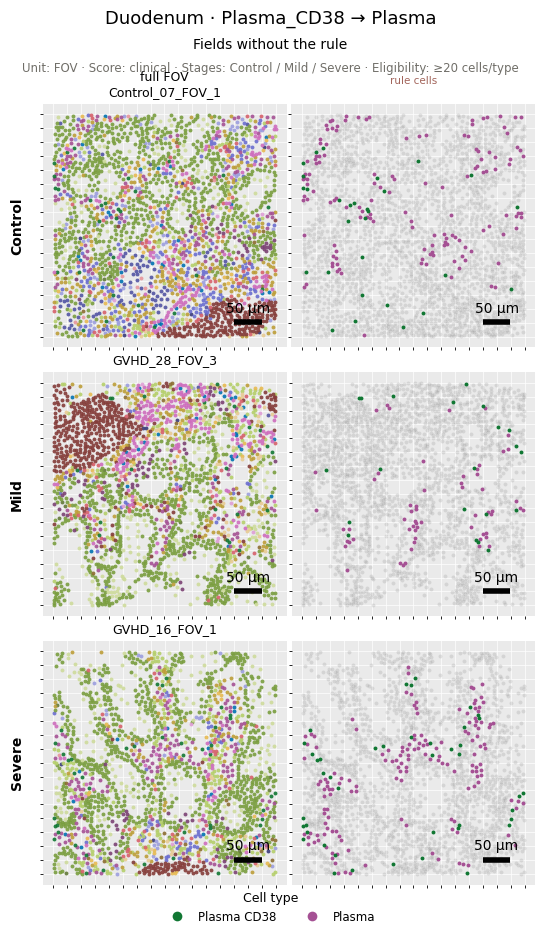

In [11]:
show_selected(5)

[6] Duodenum · Goblet -> Epithelial · attraction metric · strong visible effect
saved C:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Goblet_to_Epithelial_summary.pdf


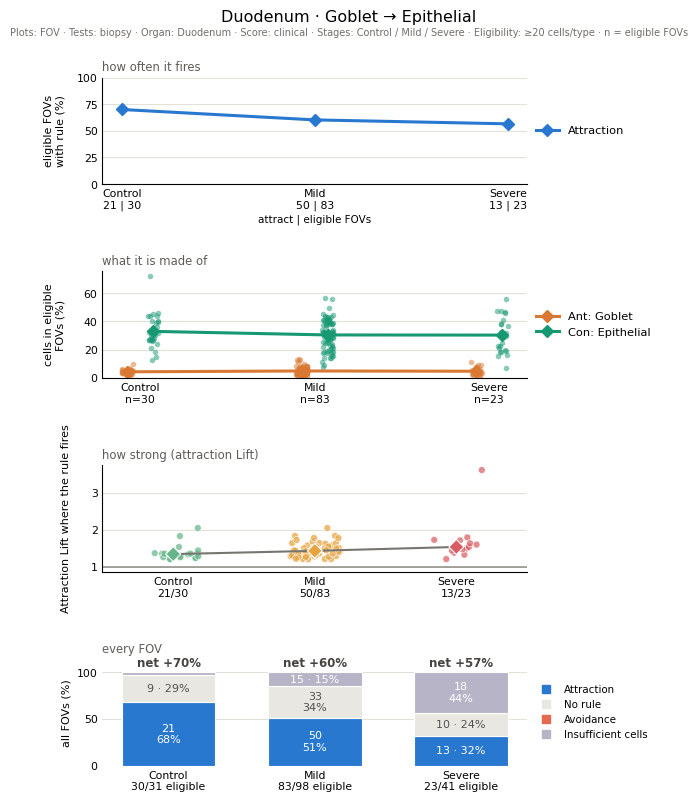

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Goblet_to_Epithelial_fovs_attraction.pdf


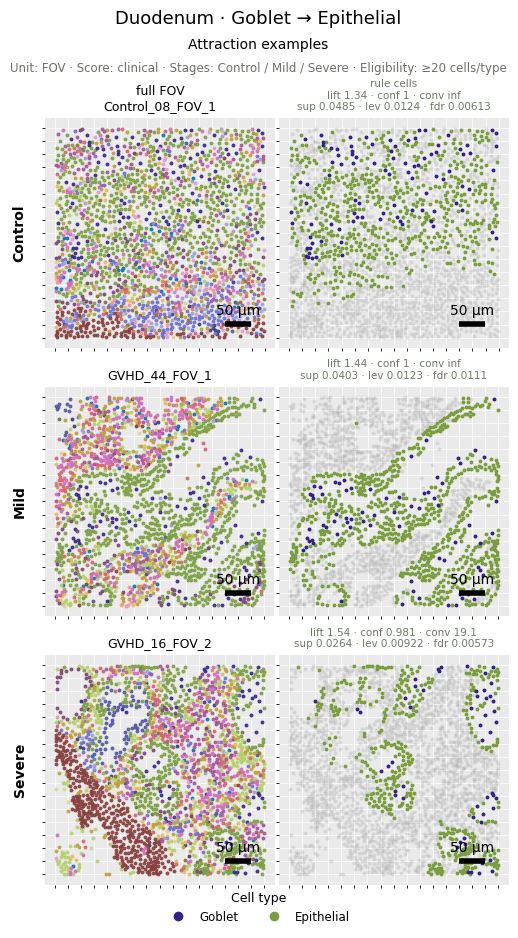

saved c:\Users\Owner\Documents\script-rule-mining\result_summary\differential_rules\summary_downloads\gap_metric_attraction_Duodenum_clinical_Goblet_to_Epithelial_fovs_no_rule.pdf


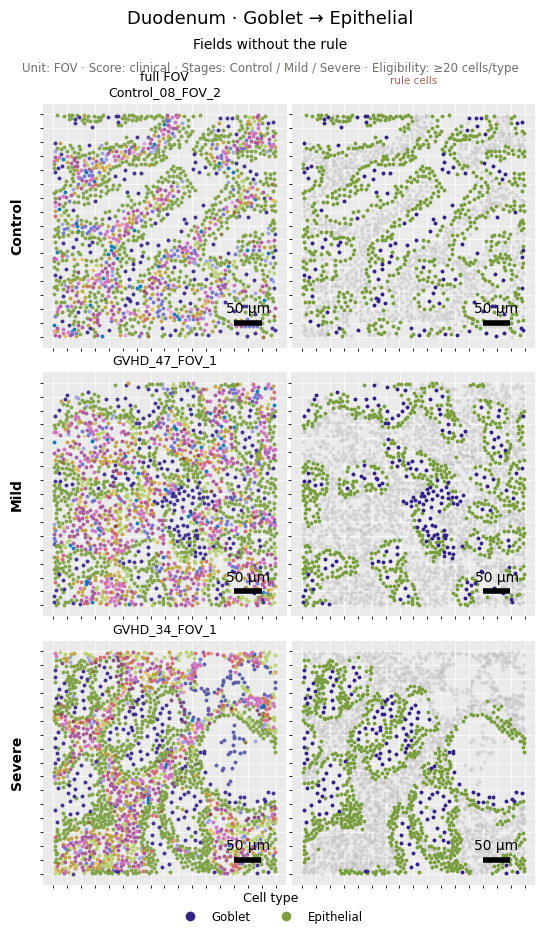

In [12]:
show_selected(6)

In [13]:
show_selected(7)

no rule at index 7; the screen selected 7


In [14]:
show_selected(8)

no rule at index 8; the screen selected 7


In [15]:
show_selected(9)

no rule at index 9; the screen selected 7


In [16]:
show_selected(10)

no rule at index 10; the screen selected 7


In [17]:
show_selected(11)

no rule at index 11; the screen selected 7


In [18]:
show_selected(12)

no rule at index 12; the screen selected 7


In [19]:
show_selected(13)

no rule at index 13; the screen selected 7


In [20]:
show_selected(14)

no rule at index 14; the screen selected 7


In [21]:
show_selected(15)

no rule at index 15; the screen selected 7


In [22]:
show_selected(16)

no rule at index 16; the screen selected 7


In [23]:
show_selected(17)

no rule at index 17; the screen selected 7


In [24]:
show_selected(18)

no rule at index 18; the screen selected 7


In [25]:
show_selected(19)

no rule at index 19; the screen selected 7


In [26]:
show_selected(20)

no rule at index 20; the screen selected 7


In [27]:
show_selected(21)

no rule at index 21; the screen selected 7


In [28]:
show_selected(22)

no rule at index 22; the screen selected 7


In [29]:
show_selected(23)

no rule at index 23; the screen selected 7
